# ZeroER++ — hyperparameter tuning (phase 1)

One Optuna study per dataset on the seeded ~30% partition; a Pareto problem over **(max F1, min surviving block pairs, max blocking recall)**, saved to `outputs/optuna.db`.

In [1]:
from pyjedai_module import ZeroEREstimator
from utils import (DATASETS, DEFAULT_TUNE_FRACTION, load_data,
                   precision_recall_f1, blocking_recall,   # objective helpers
                   tune_all, show_results, trial_budget)

/home/mda4172/Projects/data-env/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


## Search space & budget

In [ ]:
SEED = 0
SPACE = {                                     # the knobs; each key is a flat ZeroEREstimator arg
    # embeddings branch — PLM blocking. Static vectorizers (word2vec/glove/...) excluded: not LMs.
    "vectorizer": ["sminilm", "smpnet", "st5", "sdistilroberta",   # sentence-transformer PLMs
                   "bert", "distilbert", "roberta", "xlnet", "albert"],  # token PLMs
    "top_k": (1, 10),                         # neighbours kept per entity
    "similarity_distance": ["cosine", "euclidean"],
    # standard branch — syntactic blocking + cleaning
    "smoothing_factor": (1.0, 1.5),           # BlockPurging threshold
    "block_filtering_ratio": (0.5, 0.95),     # BlockFiltering keep-ratio
    "weighting_scheme": ["CBS", "ECBS", "JS", "EJS", "X2"],  # WeightedEdgePruning
    # matcher (searched in both branches)
    "c_bay": (1e-3, 3e-1),                    # ZeroER EM regularisation (log-float)
}
N_STARTUP_TRIALS = 12                          # TPE random warm-up before it models the space
N_TRIALS = trial_budget(SPACE, N_STARTUP_TRIALS)   # warm-up + ⅓ of the discrete grid = 73

## Objective

The per-experiment trial — declared here, not in `utils`, so a new experiment is just a copy-and-tweak of this cell. It returns `(F1, candset, pair_completeness)` and carries its own `directions`; `make_objective` binds it to `SPACE`/`SEED` for the runners.

In [ ]:
class TuningObjective:
    """Multi-objective trial: (max F1, min surviving block pairs, max pair completeness).

    One ``Data`` is loaded per instance and reused across trials; ``get_params``
    *is* the search space (keys map one-to-one onto the ZeroEREstimator ctor).
    """
    directions = ["maximize", "minimize", "maximize"]   # F1 up, block pairs down, PC up

    def __init__(self, dataset, space, seed=0, partition=True):
        self.space = space
        self.source_trial = None              # set by retrain_full to stamp each full trial
        self.data = load_data(dataset, partition=partition, seed=seed)
        self.attributes = DATASETS[dataset]["attributes"]
        frac = DATASETS[dataset].get("tune_fraction", DEFAULT_TUNE_FRACTION)
        scope = f"partition (frac={frac})" if partition else "full data"
        print(f"    {scope}: {self.data.num_of_entities_1}+{self.data.num_of_entities_2}"
              f" entities, {len(self.data.ground_truth)} matches", flush=True)

    def get_params(self, trial):
        # conditional: the blocker is itself a knob; each branch exposes only its
        # own stage params; c_bay (the matcher) is searched in both branches.
        s = self.space
        blocker = trial.suggest_categorical("blocker", ["embeddings", "standard"])
        params = dict(blocker=blocker,
                      c_bay=trial.suggest_float("c_bay", *s["c_bay"], log=True))
        if blocker == "embeddings":
            params.update(
                vectorizer=trial.suggest_categorical("vectorizer", s["vectorizer"]),
                top_k=trial.suggest_int("top_k", *s["top_k"]),
                similarity_distance=trial.suggest_categorical("similarity_distance", s["similarity_distance"]),
            )
        else:
            params.update(
                smoothing_factor=trial.suggest_float("smoothing_factor", *s["smoothing_factor"]),
                block_filtering_ratio=trial.suggest_float("block_filtering_ratio", *s["block_filtering_ratio"]),
                weighting_scheme=trial.suggest_categorical("weighting_scheme", s["weighting_scheme"]),
            )
        return params

    def __call__(self, trial):
        est = ZeroEREstimator(attributes=self.attributes, **self.get_params(trial))
        graph = est.fit_predict(self.data)
        _, _, f1 = precision_recall_f1(graph, self.data)
        pair_completeness = blocking_recall(est.blocks, self.data)   # gold kept by the blocker
        trial.set_user_attr("candset_size", est.candset_size)
        trial.set_user_attr("blocking_seconds", round(est.blocking_seconds, 3))
        trial.set_user_attr("em_seconds", round(est.matcher.em_time, 3))
        if self.source_trial is not None:
            trial.set_user_attr("source_trial", self.source_trial)
        return f1, est.candset_size, pair_completeness


def make_objective(dataset, partition=True):                 # factory the runners call per dataset
    return TuningObjective(dataset, SPACE, SEED, partition=partition)

## Run phase 1 — tune on the partition

Resumable: re-running continues the existing studies.

In [ ]:
tune_all(make_objective, n_trials=N_TRIALS, n_startup_trials=N_STARTUP_TRIALS, seed=SEED)

## Results

Pareto-optimal configs (best F1 first) + the fronts in the two F1 trade-off planes. Only `partition` fronts exist until `zeroer.ipynb` retrains the `full` ones.

In [ ]:
try:
    from IPython.display import display
except ImportError:
    display = print

=== partition: 5 Pareto-optimal configs across 1 dataset(s) ===


,dataset,phase,F1,candset_size,blocking_recall,blocker,vectorizer,top_k,similarity_distance,smoothing_factor,block_filtering_ratio,weighting_scheme,c_bay,blocking_seconds,em_seconds,source_trial
0,fodors_zagats,partition,0.9577,865,1.0,standard,None,None,None,1.1115,0.9287,ECBS,0.02615,0.022,0.104,None
1,fodors_zagats,partition,0.9394,484,1.0,standard,None,None,None,1.4997,0.6171,JS,0.00514,0.014,0.147,None
2,fodors_zagats,partition,0.9062,278,1.0,standard,None,None,None,1.4190,0.5432,JS,0.00174,0.016,0.166,None
3,fodors_zagats,partition,0.6126,164,1.0,standard,None,None,None,1.1481,0.5534,EJS,0.00198,0.024,0.121,None
4,fodors_zagats,partition,0.5532,45,1.0,standard,None,None,None,1.0301,0.8000,CBS,0.05347,0.017,0.107,None


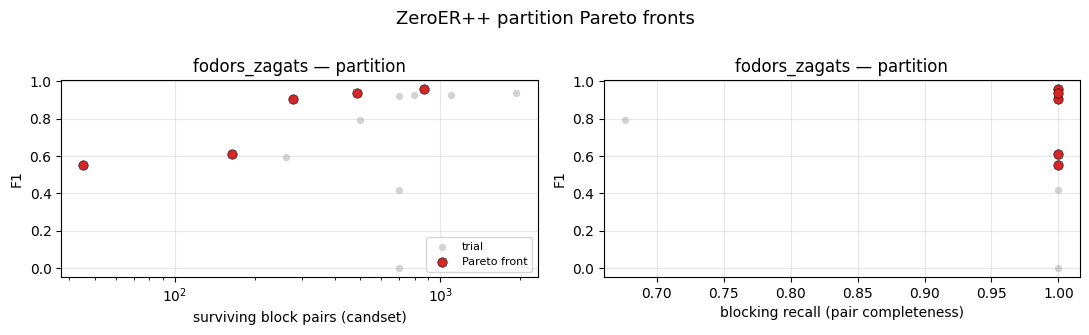

In [ ]:
show_results()

## Export CSV views

Trial logs + the partition Pareto front (`pareto_fronts.csv`) from `optuna.db`.

In [ ]:
export()